In [2]:
# import datasets

In [3]:
# dataset = datasets.load_dataset("iwslt2017", "iwslt2017-en-de", trust_remote_code=True)

In [2]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig

In [3]:
# bnb_config = BitsAndBytesConfig(load_in_4bit=True)
model = AutoModelForSeq2SeqLM.from_pretrained("./models/nllb_teacher").eval()
tokenizer = AutoTokenizer.from_pretrained("./models/nllb_teacher")

In [5]:
text = [
    "When the old man opened the small wooden door at the end of the garden, he saw a narrow path leading through the wet grass toward a quiet river, where a little girl in a red coat was feeding ducks and laughing because the wind kept turning her yellow umbrella inside out.",
    "For he did not know that beyond the lake he called home lies a deeper, darker ocean green, where waves are both wilder and more serene, to its ports I've been, to its ports I've been."
]
# text = "For he did not know that beyond the lake he called home lies a deeper, darker ocean green, where waves are both wilder and more serene, to its ports I've been, to its ports I've been."
# text = "By the time the engineer realized that the lead pipe she had been asked to wind around the old machine was actually meant to record the pressure changes rather than carry water, the supervisor, who had been present during the confusing meeting, refused to permit anyone to object until the final report was read aloud."
# text = "EX-View is a proprietary SONY technology in which the P/N junction of each photodiode in the CCD matrix is specially fabricated to have much better photon-to-electron conversion efficiency."
inputs = tokenizer(text, return_tensors="pt", padding=True).to(model.device)

In [6]:
tokenizer.batch_decode(inputs["input_ids"], skip_special_tokens=False)

['eng_Latn When the old man opened the small wooden door at the end of the garden, he saw a narrow path leading through the wet grass toward a quiet river, where a little girl in a red coat was feeding ducks and laughing because the wind kept turning her yellow umbrella inside out.</s>',
 "eng_Latn For he did not know that beyond the lake he called home lies a deeper, darker ocean green, where waves are both wilder and more serene, to its ports I've been, to its ports I've been.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>"]

In [7]:
START_TOKEN = tokenizer.convert_tokens_to_ids("rus_Cyrl")
# START_TOKEN = tokenizer.convert_tokens_to_ids("eng_Latn")

In [17]:
@torch.no_grad()
def translate_with_latency(model, tokenizer, source: str, max_len: int = 100, k: int = 0, speed: int = 1) -> str:
    inputs = tokenizer(source, return_tensors="pt", padding=True).to(model.device)
    if k <= 1:
        return model.generate(**inputs, forced_bos_token_id=START_TOKEN, max_length=max_len)

    latency_inputs = inputs["input_ids"][:, :k]
    latency_attention_mask = inputs["attention_mask"][:, :k]
    target_tokens = torch.tensor([[model.config.decoder_start_token_id, START_TOKEN]], dtype=torch.long, device=model.device)
    prefix_len = latency_inputs.shape[-1]
    i = 1

    while True:
        outputs = torch.argmax(model(
            input_ids=torch.concat([latency_inputs, torch.tensor([[tokenizer.eos_token_id]], device=model.device)], dim=-1),
            attention_mask=torch.concat([latency_attention_mask, torch.tensor([[1]], dtype=torch.long, device=model.device)], dim=-1),
            decoder_input_ids=target_tokens,
            use_cache=False
        ).logits[:, -1], dim=-1).unsqueeze(-1)

        if outputs[:, -1].item() != tokenizer.eos_token_id:
            target_tokens = torch.concat([target_tokens, outputs], dim=-1)

        print(f"Iteration {i}")
        print(f"\tInput: {tokenizer.batch_decode(latency_inputs, skip_special_tokens=True)[0]}")
        print(f"\tTarget: {tokenizer.batch_decode(target_tokens, skip_special_tokens=True)[0]}")
        # print(f"\tGenerated token: {tokenizer.batch_decode(outputs, skip_special_tokens=True)}")
        i += 1

        if k <= prefix_len:
            k += speed
            latency_inputs = inputs["input_ids"][:, :k]
            latency_attention_mask = inputs["attention_mask"][:, :k]

        prefix_len = latency_inputs.shape[-1]

        if outputs[:, -1].item() == tokenizer.eos_token_id and k >= inputs["input_ids"].shape[-1] or prefix_len >= max_len:
            break

    return tokenizer.batch_decode(target_tokens, skip_special_tokens=True)

In [18]:
translation = translate_with_latency(model, tokenizer, text, 100, 0, 1)

In [19]:
translation

tensor([[     2, 256147,  61275,   2704,  51769,  81608, 248103,  74010,  46634,
          79847,   8084, 248088,  22569, 172229, 248293,    191, 227885,  44498,
         248079,   3430,  63007,  13620,  22663,   9318, 180708, 248079,   2381,
           1351,  74672,  25219,    800,  78459, 248478,  13274,   3466,    137,
           1651,  71122,   1512,   1140, 248079,  29039,  74010,  48176, 183513,
          13202,    191,   6473,   3815, 248118, 165322,    205,  10478, 157424,
          26655,    567,    213,  13699,   2935,   1984, 248079,  58221,   3413,
           2381,   1796,  45811, 131398,  19644, 236351,  38458,  58501,  63243,
            243,   2438,  30816,    191, 226158,    229,  10807, 248075,      2],
        [     2, 256147,  11262,    467, 140990, 248079,   3413,    393,    217,
           3070,  11365, 248079, 148828,   3430, 209476,  15452,    673,  53391,
         248079,   6459, 146168,  65888,  42369,   1159,   9318, 248079,  26733,
          11344, 233199, 24

In [ ]:
k = 2
while True:
    latency_input_ids = inputs['input_ids'][:, :k]
    latency_attention_mask = inputs["attention_mask"][:, :k]
    start_target = torch.tensor([[model.config.decoder_start_token_id, START_TOKEN]], dtype=torch.long, device=model.device)

    outputs = torch.argmax(
        model(
            input_ids=torch.concat([latency_input_ids, torch.tensor([[tokenizer.eos_token_id]], device=model.device)], dim=-1),
            attention_mask=torch.concat([latency_attention_mask, torch.tensor([[1]], dtype=torch.long, device=model.device)], dim=-1),
            decoder_input_ids=start_target,
            use_cache=False
        ).logits[:, -1], dim=-1
    ).item()
    print(f"k = {k}")
    print(f"\tPrefix: {tokenizer.batch_decode(latency_input_ids, skip_special_tokens=True)[0]}")
    print(f"\tGenerated token: {tokenizer.convert_ids_to_tokens(outputs)}")

    k += 1

    if k >= inputs['input_ids'].shape[1]:
        break

In [ ]:
target_tokens

In [1]:
import json

In [22]:
k = 11
metric = "BLEU"
print(f"{metric} k = {k}")
for arch in ["transformer", "mamba", "hybrid"]:
    with open(f"./metrics/{arch}_k{k}.json", "r") as file:
        metrics = json.load(file)
        print(f"{arch}: {metrics[metric]:.4f}")

BLEU k = 11
transformer: 29.4589
mamba: 26.8823
hybrid: 35.2574


In [3]:
metrics

{'BLEU': 34.451777380053656,
 'chrF++': 56.16760712764305,
 'TER': 58.27140912530797,
 'AP': 0.7305274362183884,
 'AL': 6.32022045709876,
 'DAL': 7.0995701448791335,
 'LAAL': 6.1824544763869085,
 'ATD_text': 4.451102953246315,
 'total_time_sec': 505.1873632679999,
 'ms_per_sentence': 1.632744136479105,
 'target_tokens_per_sec': 17555.22335837843,
 'source_tokens_per_sec': 15406.68386804246,
 'first_token_latency_sec': None,
 'peak_gpu_memory_mb': 5286.4970703125,
 'generation_total_time_sec': 459.95882217303733,
 'generation_ms_per_sentence': 1.4865674094988441,
 'generation_target_tokens_per_sec': 19281.458627319444}

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from pathlib import Path

In [2]:
hybrid_loss = pd.read_csv("./metrics/hybrid.loss.csv")[["step", "value"]]
transformer_loss = pd.read_csv("./metrics/transformer.loss.csv")[["step", "value"]]
mamba_loss = pd.read_csv("./metrics/mamba.loss.csv")[["step", "value"]]
last_step = transformer_loss["step"].max()
hybrid_loss = hybrid_loss[hybrid_loss["step"] <= last_step]

In [3]:
transformer_loss

,step,value
0,1,12.456745
1,244,10.142824
2,488,8.640875
3,731,7.962287
4,975,7.753949
...,...,...
316,108240,1.488159
317,110192,1.544935
318,112136,1.235440
319,114088,1.503958


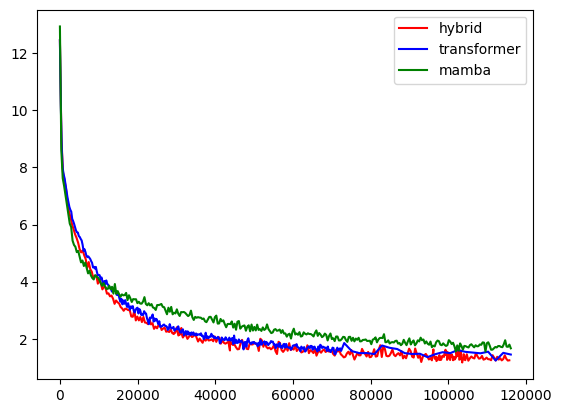

In [4]:
fig, ax = plt.subplots()

ax.plot(hybrid_loss["step"], hybrid_loss["value"], color="red")
ax.plot(transformer_loss["step"], transformer_loss["value"], color="blue")
ax.plot(mamba_loss["step"], mamba_loss["value"], color="green")
ax.legend(["hybrid", "transformer", "mamba"])
plt.show()

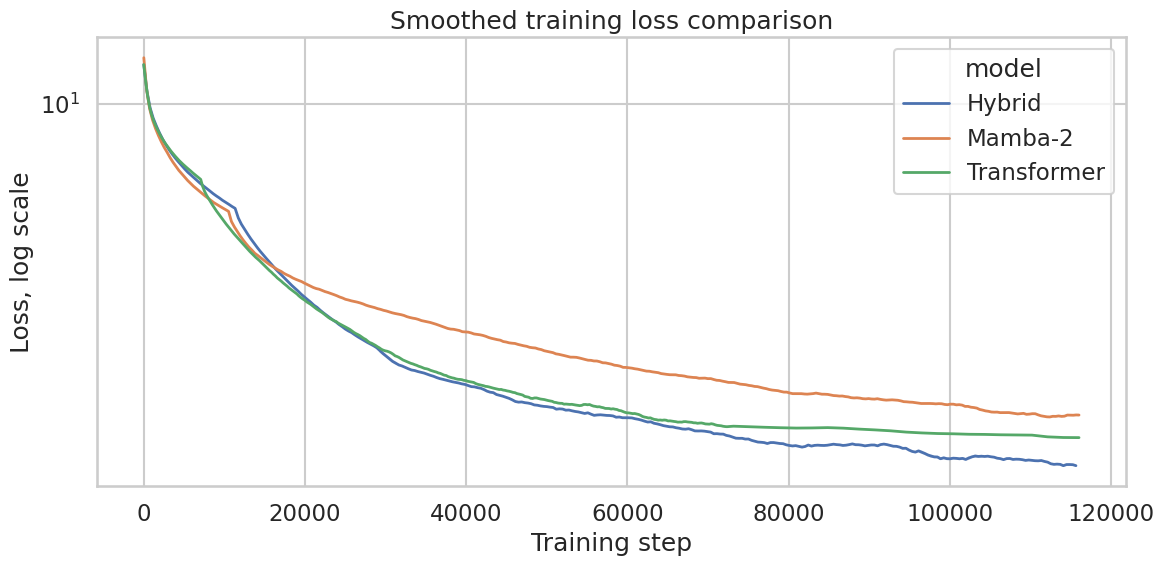

In [5]:
def add_model_name(df, model_name):
    df = df.copy()
    df["model"] = model_name
    return df

losses = pd.concat(
    [
        add_model_name(transformer_loss, "Transformer"),
        add_model_name(mamba_loss, "Mamba-2"),
        add_model_name(hybrid_loss, "Hybrid"),
    ],
    ignore_index=True,
)

sns.set_theme(style="whitegrid", context="talk")

losses = losses.sort_values(["model", "step"])

losses["loss_smooth"] = (
    losses
    .groupby("model")["value"]
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=losses,
    x="step",
    y="loss_smooth",
    hue="model",
    linewidth=2,
)

ax.set_yscale("log")

ax.set_title("Smoothed training loss comparison")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss, log scale")

plt.tight_layout()
plt.savefig("training_losses.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:



def plot_metric_by_wait_k(
    metrics_dir: str | Path,
    metric: str,
    *,
    log_y: bool = False,
    save_path: str | Path | None = None,
    figsize: tuple[int, int] = (10, 6),
):
    """
    Строит lineplot выбранной метрики по wait-k для нескольких моделей.

    Ожидаемый формат файлов:
        {model}_k{wait_k}.json

    Например:
        transformer_k1.json
        transformer_k3.json
        mamba2_k1.json
        hybrid_k5.json
    """

    metrics_dir = Path(metrics_dir)

    rows = []
    pattern = re.compile(r"(.+)_k(\d+)\.json$")

    for path in metrics_dir.glob("*.json"):
        match = pattern.match(path.name)

        if match is None:
            continue

        model_name = match.group(1)
        wait_k = int(match.group(2))

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if metric not in data:
            raise KeyError(
                f"Metric '{metric}' has not been found in {path.name}. "
                f"Available metrics: {list(data.keys())}"
            )

        rows.append(
            {
                "model": model_name,
                "wait_k": wait_k,
                "metric": metric,
                "value": data[metric],
                "file": path.name,
            }
        )

    if not rows:
        raise ValueError(f"JSON files have not been found in {metrics_dir}")

    df = pd.DataFrame(rows)
    df = df.sort_values(["model", "wait_k"])

    sns.set_theme(style="whitegrid", context="talk")

    plt.figure(figsize=figsize)

    ax = sns.lineplot(
        data=df,
        x="wait_k",
        y="value",
        hue="model",
        marker="o",
        linewidth=2,
    )

    if log_y:
        ax.set_yscale("log")

    ax.set_title(f"{metric} by wait-k")
    ax.set_xlabel("wait-k")
    ax.set_ylabel(metric)

    ax.legend(
        title="Model",
        loc="center right",
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return df

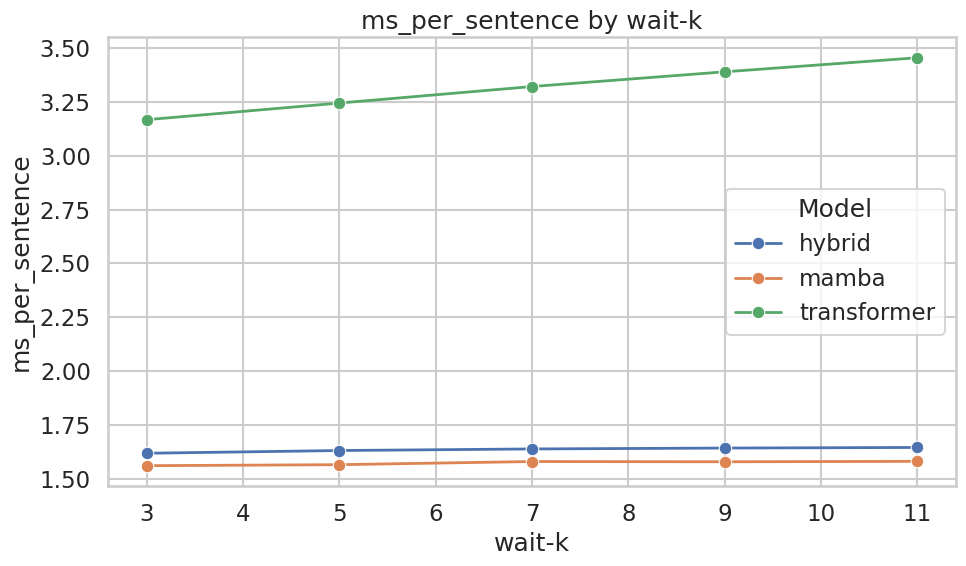

,model,wait_k,metric,value,file
1,hybrid,3,ms_per_sentence,1.620163,hybrid_k3.json
2,hybrid,5,ms_per_sentence,1.632744,hybrid_k5.json
3,hybrid,7,ms_per_sentence,1.640117,hybrid_k7.json
4,hybrid,9,ms_per_sentence,1.644211,hybrid_k9.json
0,hybrid,11,ms_per_sentence,1.647007,hybrid_k11.json
6,mamba,3,ms_per_sentence,1.562496,mamba_k3.json
7,mamba,5,ms_per_sentence,1.567179,mamba_k5.json
8,mamba,7,ms_per_sentence,1.581780,mamba_k7.json
9,mamba,9,ms_per_sentence,1.580631,mamba_k9.json
5,mamba,11,ms_per_sentence,1.582581,mamba_k11.json


In [9]:
plot_metric_by_wait_k(
    metrics_dir="./metrics",
    metric="ms_per_sentence",
    save_path="./plots/ms_per_sentence.png"
)

In [43]:
import json
import re
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_metrics_scatter_for_k(
    metrics_dir: str | Path,
    x_metric: str,
    y_metric: str,
    *,
    log_x: bool = False,
    log_y: bool = False,
    annotate: bool = True,
    save_path: str | Path | None = None,
    figsize: tuple[int, int] = (8, 6),
):
    """
    Строит scatterplot для фиксированного wait-k:
    каждая модель — одна точка.

    Ожидаемый формат файлов:
        {model}_k{wait_k}.json
    """

    metrics_dir = Path(metrics_dir)

    rows = []
    pattern = re.compile(r"(.+)_k(\d+)\.json$")

    for path in metrics_dir.glob("*.json"):
        match = pattern.match(path.name)

        if match is None:
            continue

        model_name = match.group(1)
        file_wait_k = int(match.group(2))

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        missing_metrics = [
            metric for metric in [x_metric, y_metric]
            if metric not in data
        ]

        if missing_metrics:
            raise KeyError(
                f"Metric '{metric}' has not been found in {path.name}. "
                f"Available metrics: {list(data.keys())}"
            )

        rows.append(
            {
                "model": model_name,
                "wait_k": file_wait_k,
                x_metric: data[x_metric],
                y_metric: data[y_metric],
                "file": path.name,
            }
        )

    if not rows:
        raise ValueError(f"JSON files have not been found in {metrics_dir}")

    df = pd.DataFrame(rows)

    sns.set_theme(style="whitegrid", context="talk")

    plt.figure(figsize=figsize)

    ax = sns.scatterplot(
        data=df,
        x=x_metric,
        y=y_metric,
        hue="model",
        style="model",
        s=160,
    )

    if annotate:
        for _, row in df.iterrows():
            ax.annotate(
                f"k={row["wait_k"]}",
                xy=(row[x_metric], row[y_metric]),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=10,
            )

    if log_x:
        ax.set_xscale("log")

    if log_y:
        ax.set_yscale("log")

    ax.set_title(f"{x_metric} vs {y_metric}")
    ax.set_xlabel(x_metric)
    ax.set_ylabel(y_metric)

    ax.legend(title="Model", loc="center right")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return df

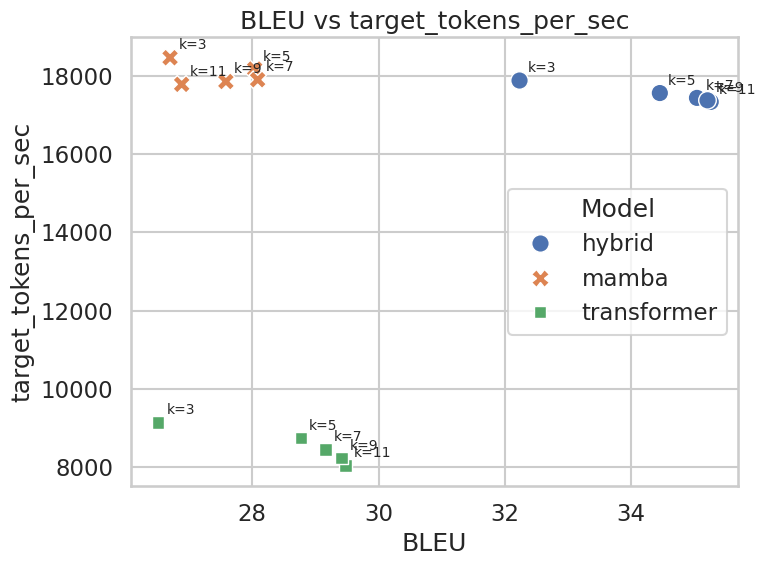

,model,wait_k,BLEU,target_tokens_per_sec,file
0,hybrid,11,35.257364,17329.070573,hybrid_k11.json
1,hybrid,3,32.230753,17874.973355,hybrid_k3.json
2,hybrid,5,34.451777,17555.223358,hybrid_k5.json
3,hybrid,7,35.039391,17431.541781,hybrid_k7.json
4,hybrid,9,35.206226,17369.494525,hybrid_k9.json
5,mamba,11,26.882325,17777.573815,mamba_k11.json
6,mamba,3,26.698419,18456.798322,mamba_k3.json
7,mamba,5,28.037715,18168.781458,mamba_k5.json
8,mamba,7,28.085253,17895.455723,mamba_k7.json
9,mamba,9,27.582087,17849.891974,mamba_k9.json


In [48]:
plot_metrics_scatter_for_k(
    metrics_dir="./metrics",
    x_metric="BLEU",
    y_metric="target_tokens_per_sec",
    save_path="./plots/bleu.target_tokents_per_sec.png",
)